##  Kütüphaneler ve Veri Yükleme

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import pickle
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_excel('verisetiTemiz2.xlsx')
print(f'✅ Veri yüklendi  →  {df.shape[0]:,} satır, {df.shape[1]} sütun')
df.head(3)

✅ Veri yüklendi  →  48,258 satır, 21 sütun


,marka,model,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,cekis,...,tramer,boyali_sayisi,degisen_sayisi,tramer_bilinmiyor,tramer_kategori,sehir,ilan_yil,ilan_ay,yas,fiyat
0,Renault_Megane,1.3 TCe Joy Comfort,124000,Otomatik,Benzin,Sedan,Beyaz,1300,138,Önden Çekiş,...,71300,0,1,0,yuksek,Adana,2025,8,3,1169000
1,Skoda_Octavia,1.0 e-Tec Elite,99000,Otomatik,Hibrit,Sedan,Gri,1300,113,Önden Çekiş,...,56060,1,0,0,yuksek,Adana,2025,8,3,1520000
2,Peugeot_207,1.4 Trendy,207500,Düz,LPG & Benzin,Hatchback/5,Gri,1400,91,Önden Çekiş,...,0,0,0,0,bilinmiyor,Adana,2025,8,16,469999


## Eğitim / Test Ayrımı

In [5]:
X = df.drop(columns=['fiyat'])
y = df['fiyat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Eğitim seti : {X_train.shape[0]:>6,} satır')
print(f'Test seti   : {X_test.shape[0]:>6,} satır')
print(f'Özellik sayısı: {X_train.shape[1]}')

Eğitim seti : 38,606 satır
Test seti   :  9,652 satır
Özellik sayısı: 20


## Kategorik Sutunları Sayısal Sutunlara Çevirme

In [7]:

cat_cols = ['marka','model', 'vites_tipi', 'yakit_tipi', 'kasa_tipi',
            'renk', 'cekis', 'kimden', 'tramer_kategori', 'sehir']

# Az seçenekli olanlar (OHE yapılacaklar)
low_card_cols = ['vites_tipi', 'yakit_tipi', 'kasa_tipi', 'renk', 'cekis', 'kimden', 'tramer_kategori']

# Çok seçenekli olanlar (Target Encoding yapılacaklar - Fiyatı bozanlar bunlardı)
high_card_cols = ['marka', 'model', 'sehir']

X_train = pd.get_dummies(X_train, columns=low_card_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=low_card_cols, drop_first=True)

# ÖNEMLİ: Eğitim setinde olup test setinde olmayan bir "renk" veya "tramer" çıkarsa diye,
# iki tabloyu birbirine hizalıyoruz. Eksik sütunları 0 ile doldurur.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ---------------------------------------------------------
# 4. ADIM: ÇOK SEÇENEKLİLER İÇİN TARGET ENCODING
# ---------------------------------------------------------
target_encoder = ce.TargetEncoder(cols=high_card_cols)

# a) Eğitim setinde fiyata bakarak ÖĞREN ve UYGULA
X_train[high_card_cols] = target_encoder.fit_transform(X_train[high_card_cols], y_train)

# b) Test setinde fiyata bakmadan SADECE UYGULA (Kopya çekmek yasak!)
X_test[high_card_cols] = target_encoder.transform(X_test[high_card_cols])

print("İşlem Başarılı! Yeni boyutlar:")
print(f"X_train sütun sayısı: {X_train.shape[1]}")
print(f"X_test sütun sayısı: {X_test.shape[1]}")


İşlem Başarılı! Yeni boyutlar:
X_train sütun sayısı: 50
X_test sütun sayısı: 50


## Random Forest Modelinin Eğitilmesi

In [9]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('Random Forest (LOG) eğitiliyor...')

# 1. Target'ı log'a çevir
y_train_log = np.log1p(y_train)

# 🔥 AĞACI BUDADIK: Overfitting'i engellemek için parametreleri sıkılaştırdık
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,             # Ağaç en fazla 15 soru sorabilsin (Derinlik sınırı)
    min_samples_split=10,     # Bir dalın bölünmesi için en az 10 araç olsun
    min_samples_leaf=5,       # En uç yaprakta en az 5 araç kalsın (Tek araba ezberlemesin)
    n_jobs=-1,
    random_state=42
)

# 2. Modeli eğit
rf_model.fit(X_train, y_train_log)

# 3. Hem Eğitim hem Test seti için tahmin yap (log scale)
y_pred_train_log = rf_model.predict(X_train)
y_pred_test_log = rf_model.predict(X_test)

# 4. Geri dönüştür (expm1)
y_pred_train_rf = np.expm1(y_pred_train_log)
y_pred_test_rf = np.expm1(y_pred_test_log)

# 5. Metrikler (Eğitim ve Test Karşılaştırması)
# Eğitim Metrikleri
r2_train = r2_score(y_train, y_pred_train_rf)
mape_train = np.mean(np.abs((y_train - y_pred_train_rf) / y_train)) * 100

# Test Metrikleri
r2_test = r2_score(y_test, y_pred_test_rf)
mae_test = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mape_test = np.mean(np.abs((y_test - y_pred_test_rf) / y_test)) * 100

print(f'\n Random Forest (LOG) Aşırı Öğrenme Testi Sonuçları')
print('-'*40)
print(f'   Eğitim (Train) R²   : {r2_train:.4f}  | Eğitim MAPE: {mape_train:.2f}%')
print(f'   Test (Validation) R²: {r2_test:.4f}  | Test MAPE  : {mape_test:.2f}%')
print('-'*40)
print(f'   Test MAE            : {mae_test:.2f} TL')
print(f'   Test RMSE           : {rmse_test:.2f} TL')

Random Forest (LOG) eğitiliyor...

 Random Forest (LOG) Aşırı Öğrenme Testi Sonuçları
----------------------------------------
   Eğitim (Train) R²   : 0.9780  | Eğitim MAPE: 7.62%
   Test (Validation) R²: 0.9577  | Test MAPE  : 10.55%
----------------------------------------
   Test MAE            : 60524.85 TL
   Test RMSE           : 95433.64 TL


## Özelliklerin Fiyata Etkisi (Top 20)

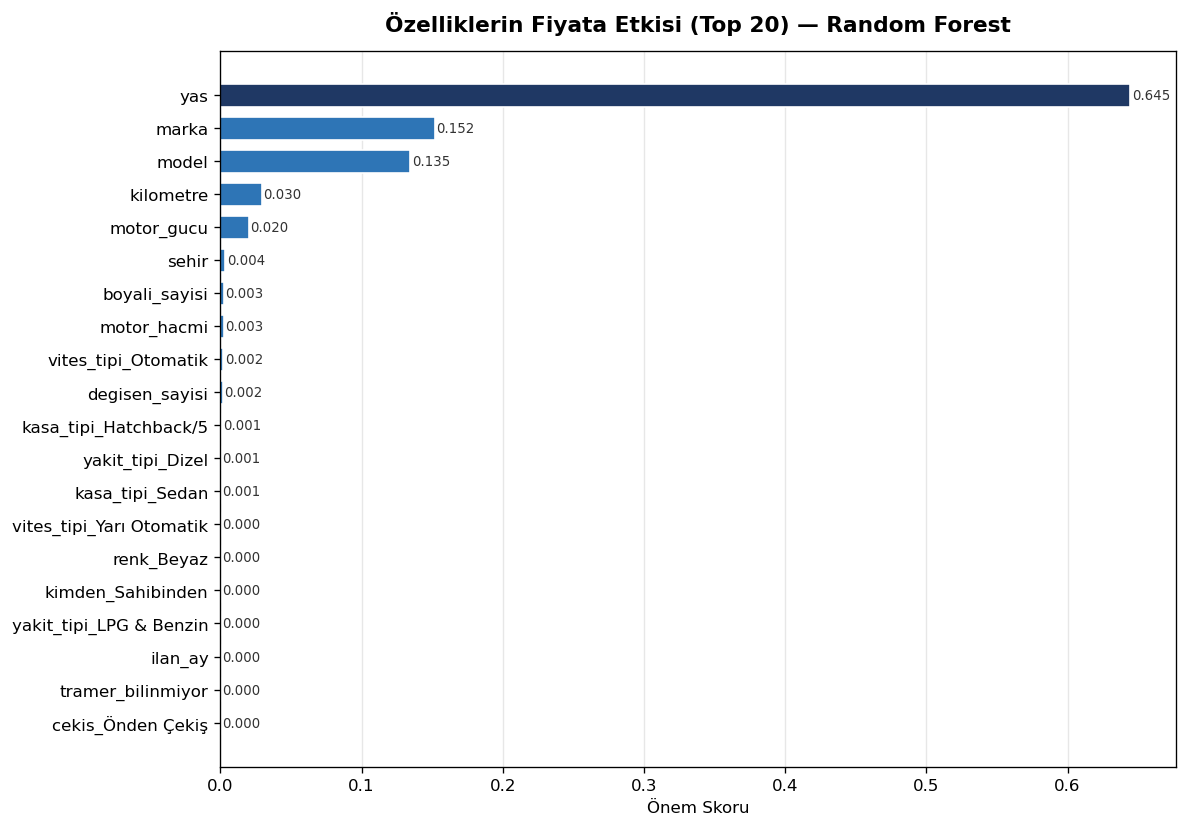

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# DÜZELTME BURADA: X.columns yerine modeli eğittiğimiz X_train.columns'u kullanıyoruz
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

# Renkleri belirle (en yüksek olanlar daha koyu)
colors = ['#2E75B6' if v < top20.max() * 0.6 else '#1F3864' for v in top20]
bars = ax.barh(top20.index, top20.values, color=colors, edgecolor='white', height=0.7)

# Bar sonlarına sayısal değerleri yazdır
for bar, val in zip(bars, top20.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=8, color='#333')

ax.set_title('Özelliklerin Fiyata Etkisi (Top 20) — Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Önem Skoru', fontsize=10)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ozellik_onemi_yeni_model.png', bbox_inches='tight')
plt.show()

## Gerçek vs Tahmin Grafiği

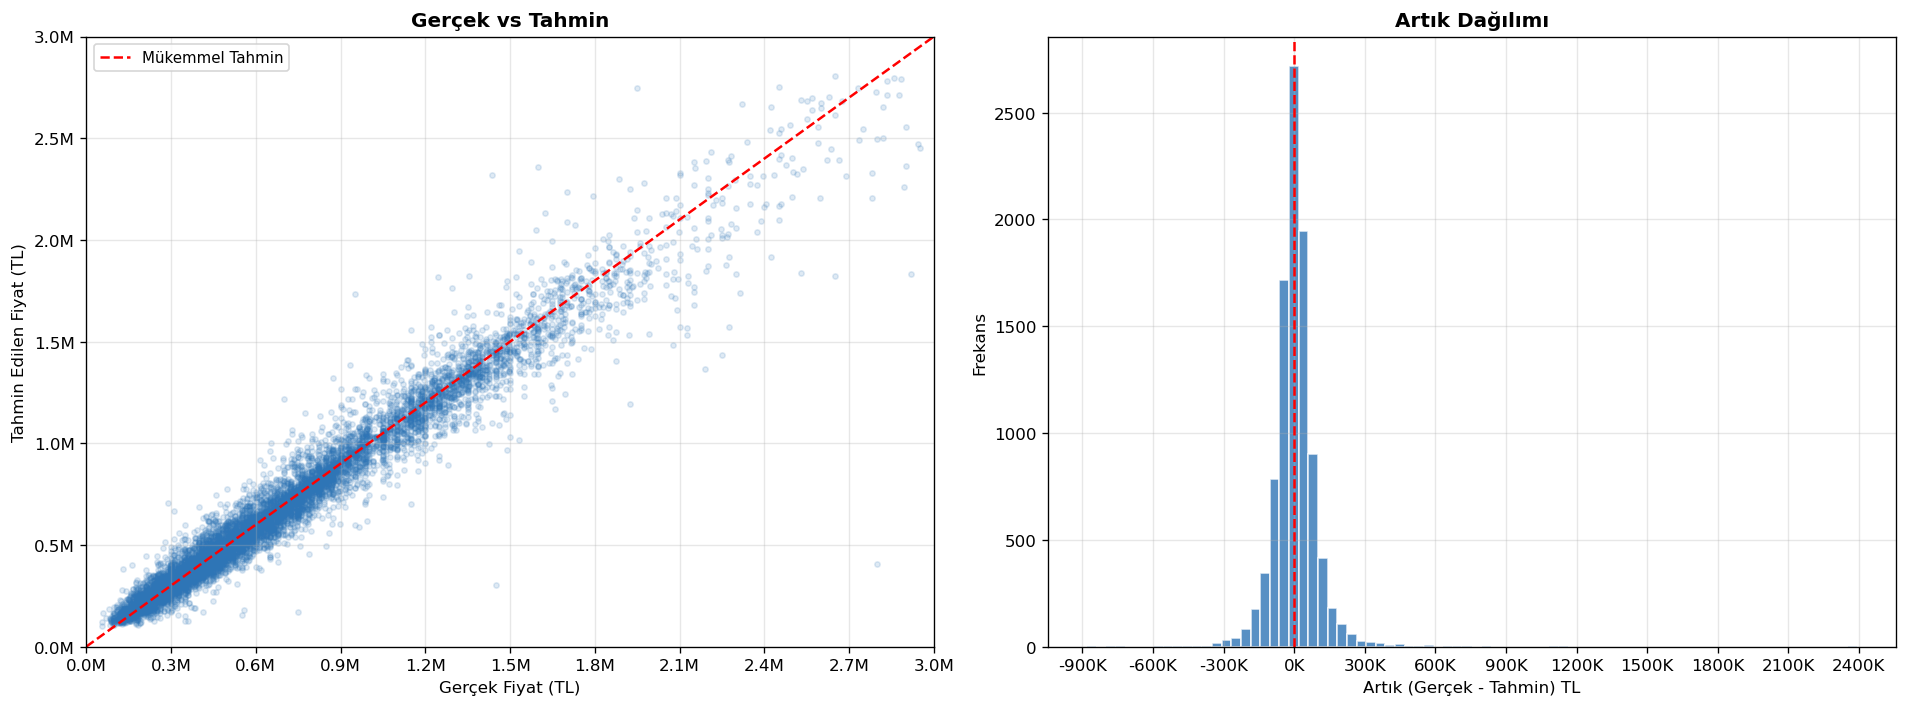

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import io
from PIL import Image
import numpy as np
# --- KRİTİK ADIM: Boyut hatasını engellemek için tahmini test setiyle yeniden yapıyoruz ---
# Eğer rf_model eğitildiyse, sadece X_test için tahmin almalıyız
y_pred_best = np.expm1(rf_model.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Sol Grafik: Gerçek vs Tahmin ---
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.15, s=10, color='#2E75B6')
lims = [0, 3_000_000]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Mükemmel Tahmin')
ax.set_xlim(lims)
ax.set_ylim(lims)

# X eksenini 300.000 birimde bir ayarla
ax.xaxis.set_major_locator(mticker.MultipleLocator(300_000))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

ax.set_xlabel('Gerçek Fiyat (TL)', fontsize=10)
ax.set_ylabel('Tahmin Edilen Fiyat (TL)', fontsize=10)
ax.set_title('Gerçek vs Tahmin', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Sağ Grafik: Artık (Residual) Dağılımı ---
ax2 = axes[1]
# y_test bir Pandas Series ise .values kullanmak boyutsal hataları önler
residuals = y_test.values.flatten() - y_pred_best.flatten() 

ax2.hist(residuals, bins=80, color='#2E75B6', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)

# Sağ grafiğin X eksenini de 300.000 birimde bir ayarla
ax2.xaxis.set_major_locator(mticker.MultipleLocator(300_000))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

ax2.set_xlabel('Artık (Gerçek - Tahmin) TL', fontsize=10)
ax2.set_ylabel('Frekans', fontsize=10)
ax2.set_title('Artık Dağılımı', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
buf = io.BytesIO()
fig.savefig(buf)
buf.seek(0)
img = Image.open(buf)
# Save image with the help of save() Function.
img.save('Grafik.png')
plt.tight_layout()
plt.show()

## Test Verisi Tahmin Tablosu (400 Örnek)

In [18]:
# Orijinal test satırlarını geri al
df_orijinal = pd.read_excel('verisetiTemiz2.xlsx')

test_idx = X_test.index

df_sonuc = df_orijinal.loc[test_idx, ['marka', 'model', 'kilometre','vites_tipi', 'yakit_tipi','kasa_tipi','renk','motor_hacmi','motor_gucu',
                                       'cekis','kimden','tramer','boyali_sayisi','degisen_sayisi','tramer_bilinmiyor','tramer_kategori','sehir','ilan_yil','ilan_ay','yas','fiyat']].copy()
df_sonuc.rename(columns={'fiyat': 'gercek_fiyat'}, inplace=True)
df_sonuc['tahmin_fiyat'] = y_pred_best.astype(int)
df_sonuc['fark_tl']      = df_sonuc['tahmin_fiyat'] - df_sonuc['gercek_fiyat']
df_sonuc['hata_%']       = (df_sonuc['fark_tl'].abs() / df_sonuc['gercek_fiyat'] * 100).round(1)

# Küçük, orta, büyük fiyat aralıklarından dengeli 400 örnek al
dusuk  = df_sonuc[df_sonuc['gercek_fiyat'] <  400_000].sample(100, random_state=42)
orta   = df_sonuc[(df_sonuc['gercek_fiyat'] >= 400_000) & (df_sonuc['gercek_fiyat'] < 1_000_000)].sample(100, random_state=42)
yuksek = df_sonuc[(df_sonuc['gercek_fiyat'] >= 1_000_000)& (df_sonuc['gercek_fiyat'] < 2_000_000)].sample(100, random_state=42)
cok_yuksek = df_sonuc[df_sonuc['gercek_fiyat'] >= 2_000_000].sample(100, random_state=42)

ornek  = pd.concat([dusuk, orta, yuksek,cok_yuksek]).reset_index(drop=True)
ornek.index += 1

# Formatla
def fmt(x): return f'{int(x):,}'
ornek['gercek_fiyat']  = ornek['gercek_fiyat'].apply(fmt)
ornek['tahmin_fiyat']  = ornek['tahmin_fiyat'].apply(fmt)
ornek['fark_tl']       = ornek['fark_tl'].apply(lambda x: f'+{int(x):,}' if x>0 else f'{int(x):,}')
ornek['hata_%']        = ornek['hata_%'].apply(lambda x: f'%{x}')

display(ornek.style
        .set_caption('📋 Test Seti Tahmin Örnekleri — 400 Araç (Düşük / Orta /Yuksek/Cok Yüksek Fiyat)')
        .set_properties(**{'font-size': '11px'})
        .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]}]))

## Hata Analizi — Fiyat Dilimi Bazında MAPE

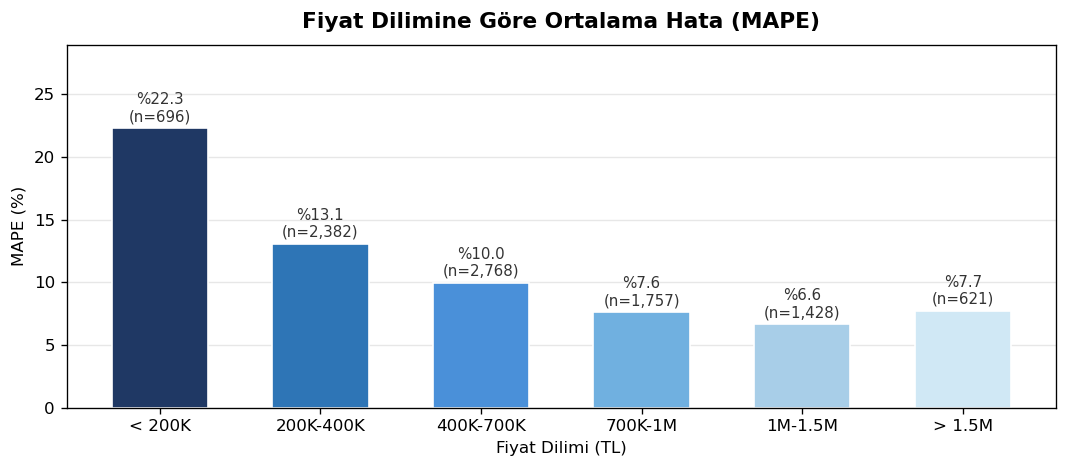

In [19]:
# Tüm test seti üzerinde fiyat dilimi bazında hata hesapla
df_hata = pd.DataFrame({'gercek': y_test.values, 'tahmin': y_pred_best})
df_hata['hata_pct'] = (df_hata['gercek'] - df_hata['tahmin']).abs() / df_hata['gercek'] * 100
df_hata['dilim'] = pd.cut(df_hata['gercek'],
    bins=[0, 200_000, 400_000, 700_000, 1_000_000, 1_500_000, 3_100_000],
    labels=['< 200K', '200K-400K', '400K-700K', '700K-1M', '1M-1.5M', '> 1.5M'])

mape_dilim = df_hata.groupby('dilim', observed=True)['hata_pct'].mean().round(2)
counts     = df_hata.groupby('dilim', observed=True).size()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(mape_dilim.index.astype(str), mape_dilim.values,
              color=['#1F3864','#2E75B6','#4A90D9','#70B0E0','#A8CEE8','#D0E8F5'],
              edgecolor='white', width=0.6)
for bar, (mape_v, cnt) in zip(bars, zip(mape_dilim.values, counts.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'%{mape_v:.1f}\n(n={cnt:,})', ha='center', va='bottom', fontsize=9, color='#333')

ax.set_title('Fiyat Dilimine Göre Ortalama Hata (MAPE)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Fiyat Dilimi (TL)', fontsize=10)
ax.set_ylabel('MAPE (%)', fontsize=10)
ax.set_ylim(0, mape_dilim.max() * 1.3)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('mape_dilim.png', bbox_inches='tight')
plt.show()

In [22]:
import pickle
import numpy as np

import joblib

# 1. Target Encoder'ı kaydet
joblib.dump(target_encoder, 'target_encoder.pkl')

# 2. Random Forest Modelini kaydet
joblib.dump(rf_model, 'arac_fiyat_modeli.pkl')

print("✅ Model ve Encoder başarıyla PKL olarak kaydedildi!")

✅ Model ve Encoder başarıyla PKL olarak kaydedildi!
